# Assignment: Temporal-Difference Control in Mountain Car

_Study and Compare On-Policy and Off-Policy TD Control Methods using Continuous-State RL Environment_

In [1]:
import gymnasium as gym
# from gymnasium.wrappers import RecordVideo, RecordEpisodeStatistics
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/hegemon/RL-Assignments/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Environment: Mountain Car

Determinstic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley.

## Observation Space
`ndarray` of shape `(2,)` with the following values:
- `ndarray[0]`: Car's position, a float in the range `[-1.2, 0.6]`
- `ndarray[1]`: Car's velocity, a float in the range `[-0.07, 0.07]`

## Action Space
`Discrete(3)` with the following actions:
- `0`: Accelerate to the left
- `1`: Don't accelerate
- `2`: Accelerate to the right

## Transition Dynamics
The car's position and velocity are updated according to the following equations:
```
velocity = velocity + (action - 1) * 0.001 - cos(3 * position) * (0.0025)
position = position + velocity
position = clip(position, -1.2, 0.6)
velocity = clip(velocity, -0.07, 0.07)
```
Upon collision with either boundary, the car's velocity is reset to `0`.

## Reward
Reward of `-1` is given at every time step until the car reaches the goal. The goal is to reach the flag at position `0.5` or greater.

## Starting State
The car starts at a random position between `-0.6` and `-0.4` with zero velocity.

## Episode End
Episode ends when:
1. The car reaches the goal (position `>= 0.5`).
2. The car fails to reach the goal within `200` time steps.

In [2]:
NUM_EPISODES = 200

env = gym.make("MountainCar-v0", render_mode="rgb_array")
spec = env.spec
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")
print(f"Max Episode Steps: {spec.max_episode_steps}")
print(f"Lower Bounds: {env.observation_space.low}")
print(f"Upper Bounds: {env.observation_space.high}")
env.close()

Observation Space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Action Space: Discrete(3)
Max Episode Steps: 200
Lower Bounds: [-1.2  -0.07]
Upper Bounds: [0.6  0.07]


# Function Approximation

For both algorithms, I'll use a linear function approximator for the action-value function:
$$\hat{q}(s, a; w) = w^T \phi(s, a)$$
where $\phi(s, a)$ is a feature vector representing the state-action pair, and $w$ is the weight vector to be learned.

The feature vector $\phi(s, a)$ will be constructed using tile coding to discretize the continuous state space into a binary feature representation. Each tile will correspond to a specific region of the state space, and the feature vector will have a value of `1` for the active tiles corresponding to the current state-action pair and `0` for all other tiles.

![Tile Coding Example](tile_coding.png)

In [ ]:
class TileCoder:
    """
    Tile coder for linear function approximation in continuous-state RL.
    """

    def __init__(self, low, high, n_actions, n_tilings=8, bins=(8, 8)):
        # Store state bounds as float arrays for stable arithmetic.
        self.low = np.asarray(low, dtype=np.float64)
        self.high = np.asarray(high, dtype=np.float64)

        # Number of discrete actions in the environment (MountainCar: 3).
        self.n_actions = n_actions

        # Number of overlapping tilings. More tilings -> smoother generalization,
        # but larger feature vector.
        self.n_tilings = n_tilings

        # Number of bins per state dimension inside each tiling.
        # For MountainCar with 2D state, bins=(8, 8). Since we care for both position and velocity, we use equal number of bins for each dimension.
        self.bins = np.asarray(bins, dtype=np.int32)

        # Number of tiles in a single tiling (product of bins across dimensions).
        self.tiles_per_tiling = int(np.prod(self.bins))

        # Per-action feature count: each action has its own tile-coded block.
        self.features_per_action = self.n_tilings * self.tiles_per_tiling

        # Total feature count across all actions.
        self.total_features = self.n_actions * self.features_per_action

        # Tile "width" in each state dimension.
        # Using (bins - 1) ensures full span from low to high is covered.
        self.tile_size = (self.high - self.low) / (self.bins - 1)

        # Asymmetric offsets per tiling (The book suggests doing assymetrical offsets to avoid diagonal tiling patterns that can lead to poor generalization.):
        # - Shift each tiling differently so states activate different tiles across tilings.
        multipliers = np.array([1.0, np.sqrt(2) - 1.0])

        self.offsets = []
        for k in range(self.n_tilings):
            # Fraction increases with tiling index (1/n, 2/n, ..., n/n).
            frac = (k + 1) / self.n_tilings

            # Compute per-dimension offset, wrap into [0, 1) with modulo,
            # then scale by tile size to convert to state units.
            off = ((multipliers * frac) % 1.0) * self.tile_size
            self.offsets.append(off)

        # Shape: (n_tilings, state_dim)
        self.offsets = np.asarray(self.offsets)

    def get_active_features(self, state, action):
        """
        Return indices of active features for a given (state, action).

        Output:
            active: np.ndarray of shape (n_tilings,), dtype=int32
                    One active feature index per tiling.
        """
        s = np.clip(np.asarray(state, dtype=np.float64), self.low, self.high)

        # Will hold one global feature index per tiling.
        active = np.empty(self.n_tilings, dtype=np.int32)

        # Offset into the chosen action's feature block.
        action_base = action * self.features_per_action

        for t in range(self.n_tilings):
            # Shift state by this tiling's offset, then convert to tile coordinates.
            coords = ((s - self.low + self.offsets[t]) / self.tile_size).astype(np.int32)

            # Ensure coordinates stay inside valid bin range.
            coords = np.clip(coords, 0, self.bins - 1)

            # Convert multi-dimensional tile coords -> flat index within this tiling.
            flat = self.bins[0] * coords[0] + coords[1]

            # Build global feature index:
            # action block + tiling block + flat tile index.
            active[t] = action_base + t * self.tiles_per_tiling + flat

        return active


# Instantiate tile coder using environment bounds and action count.
tc = TileCoder(
    low=env.observation_space.low,
    high=env.observation_space.high,
    n_actions=env.action_space.n
)

# Example query: active features for a sample state/action pair.
active_features = tc.get_active_features(state=[-0.5, 0.02], action=1)
print(f"Active feature indices for state [-0.5, 0.02] and action 1: {active_features}")
assert active_features.shape == (tc.n_tilings,)
assert np.all(active_features >= 0) and np.all(active_features < tc.total_features)

Active feature indices for state [-0.5, 0.02] and action 1: [532 596 668 732 796 860 924 980]


# SARSA: On-Policy TD Control using Function Approximation

**I'll implement the Episodic Semi-Gradient SARSA Control Algorithm for estimating $\hat{q} \approx q^*$.**

# Q-Learning: Off-Policy TD Control using Function Approximation

**I'll implement the Episodic Semi-Gradient Q-Learning Control Algorithm for estimating $\hat{q} \approx q^*$.**

**Importance Sampling Note:**

1. Although, The Chapter 11 of the book requires the use of on-policy distribution($\mu$) for the update to repurpose the semi-gradient TD(0) method to off-policy case, since the mountain car environment is quite simple, I will forego the use of **importance sampling** and directly use the greedy policy for the update.

In [7]:
# q(s, a) = sum(weights[active_features])

def q_value(weights, tc, state, action):
    idx = tc.get_active_features(state, action)
    return weights[idx].sum()



def epsilon_greedy(weights, tc, state, epsilon, rng):
    if rng.random() < epsilon:
        return rng.integers(tc.n_actions)
    q_vals = np.array([q_value(weights, tc, state, a) for a in range(tc.n_actions)])
    best = np.flatnonzero(q_vals == q_vals.max())
    return int(rng.choice(best))

In [6]:
# Feature-map / algorithm hyperparameters
n_tilings = 8
bins = (8, 8)
gamma = 1.0
alpha = 0.4 / n_tilings  # effective step-size (scaled by tilings)

def epsilon_by_episode(
    ep,
    num_episodes,
    mode="fixed",
    epsilon_fixed=0.1,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_ratio=0.8,
 ):
    """Return epsilon for episode `ep` under fixed or linear-decay schedules."""
    if mode == "fixed":
        return float(epsilon_fixed)
    if mode == "decay":
        decay_steps = max(1, int(num_episodes * epsilon_decay_ratio))
        return float(
            epsilon_end
            + (epsilon_start - epsilon_end) * max(0, (decay_steps - ep)) / decay_steps
        )
    raise ValueError("epsilon mode must be either 'fixed' or 'decay'")


def moving_average(x, window=50):
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")


## SARSA with Function Approximation Implementation

### Pseudocode
```python
Input: 
1. a differentiable action-value function approximator Q with weights w, 
2. learning rate α ∈ (0, 1], 
3. exploration rate ε ∈ [0, 1]


Loop for each episode:
    S, A ← initialize S, A (e.g., using ε-greedy policy derived from Q)
    Loop for each step of episode:
        Take action A, observe R, S'
        If S' is terminal:
            w ← w + α(R - Q(S, A; w))∇w Q(S, A; w)
            Go to next episode
        Choose A' from S' using policy derived from Q (e.g., ε-greedy)
        w ← w + α(R + Q(S', A'; w) - Q(S, A; w))∇w Q(S, A; w)
        S ← S'; A ← A'
```

In [8]:
def train_sarsa_tile(
    num_episodes=NUM_EPISODES,
    alpha=alpha,
    gamma=gamma,
    n_tilings=n_tilings,
    bins=bins,
    epsilon_mode="fixed",
    epsilon_fixed=0.1,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_ratio=0.8,
    seed=0,
 ):
    env_local = gym.make("MountainCar-v0", render_mode="rgb_array")
    rng_local = np.random.default_rng(seed)

    tc_local = TileCoder(
        low=env_local.observation_space.low,
        high=env_local.observation_space.high,
        n_actions=env_local.action_space.n,
        n_tilings=n_tilings,
        bins=bins,
    )

    w = np.zeros(tc_local.total_features, dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    lengths = np.zeros(num_episodes, dtype=np.int32)
    eps_used = np.zeros(num_episodes, dtype=np.float64)

    for ep in tqdm(range(num_episodes), desc=f"Training SARSA ({epsilon_mode})"):
        epsilon = epsilon_by_episode(
            ep,
            num_episodes,
            mode=epsilon_mode,
            epsilon_fixed=epsilon_fixed,
            epsilon_start=epsilon_start,
            epsilon_end=epsilon_end,
            epsilon_decay_ratio=epsilon_decay_ratio,
        )
        eps_used[ep] = epsilon

        state, _ = env_local.reset()
        action = epsilon_greedy(w, tc_local, state, epsilon, rng_local)

        total_reward = 0.0
        steps = 0

        while True:
            next_state, reward, terminated, truncated, _ = env_local.step(action)
            done = terminated or truncated

            sa_idx = tc_local.get_active_features(state, action)
            q_sa = w[sa_idx].sum()

            if done:
                target = reward
                w[sa_idx] += alpha * (target - q_sa)
                total_reward += reward
                steps += 1
                break

            next_action = epsilon_greedy(w, tc_local, next_state, epsilon, rng_local)
            target = reward + gamma * q_value(w, tc_local, next_state, next_action)
            w[sa_idx] += alpha * (target - q_sa)

            total_reward += reward
            steps += 1
            state, action = next_state, next_action

        returns[ep] = total_reward
        lengths[ep] = steps

    env_local.close()
    return {
        "weights": w,
        "returns": returns,
        "lengths": lengths,
        "epsilons": eps_used,
        "tc": tc_local,
        "rng": rng_local,
    }

## Q-Learning with Function Approximation Implementation

### Pseudocode
```python
Input: 
1. a differentiable action-value function approximator Q with weights w, 
2. learning rate α ∈ (0, 1], 
3. exploration rate ε ∈ [0, 1]

Loop for each episode:
    S ← initialize S (e.g., randomly)
    Loop for each step of episode:
        Choose A from S using policy derived from Q (e.g., ε-greedy)
        Take action A, observe R, S'
        If S' is terminal:
            w ← w + α(R - Q(S, A; w))∇w Q(S, A; w)
            Go to next episode
        w ← w + α(R + max_a' Q(S', a'; w) - Q(S, A; w))∇w Q(S, A; w)
        S ← S'
```

In [9]:
def train_q_learning_tile(
    num_episodes=NUM_EPISODES,
    alpha=alpha,
    gamma=gamma,
    n_tilings=n_tilings,
    bins=bins,
    epsilon_mode="fixed",
    epsilon_fixed=0.1,
    epsilon_start=1.0,
    epsilon_end=0.05,
    epsilon_decay_ratio=0.8,
    seed=0,
 ):
    """Episodic semi-gradient Q-Learning with tile coding."""
    env_local = gym.make("MountainCar-v0", render_mode="rgb_array")
    rng_local = np.random.default_rng(seed)

    tc_local = TileCoder(
        low=env_local.observation_space.low,
        high=env_local.observation_space.high,
        n_actions=env_local.action_space.n,
        n_tilings=n_tilings,
        bins=bins,
    )

    w = np.zeros(tc_local.total_features, dtype=np.float64)
    returns = np.zeros(num_episodes, dtype=np.float64)
    lengths = np.zeros(num_episodes, dtype=np.int32)
    eps_used = np.zeros(num_episodes, dtype=np.float64)

    for ep in tqdm(range(num_episodes), desc=f"Training Q-Learning ({epsilon_mode})"):
        epsilon = epsilon_by_episode(
            ep,
            num_episodes,
            mode=epsilon_mode,
            epsilon_fixed=epsilon_fixed,
            epsilon_start=epsilon_start,
            epsilon_end=epsilon_end,
            epsilon_decay_ratio=epsilon_decay_ratio,
        )
        eps_used[ep] = epsilon

        state, _ = env_local.reset()
        total_reward = 0.0
        steps = 0

        while True:
            action = epsilon_greedy(w, tc_local, state, epsilon, rng_local)
            next_state, reward, terminated, truncated, _ = env_local.step(action)
            done = terminated or truncated

            sa_idx = tc_local.get_active_features(state, action)
            q_sa = w[sa_idx].sum()

            if done:
                target = reward
            else:
                q_next_max = max(q_value(w, tc_local, next_state, a) for a in range(tc_local.n_actions))
                target = reward + gamma * q_next_max

            w[sa_idx] += alpha * (target - q_sa)

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        returns[ep] = total_reward
        lengths[ep] = steps

    env_local.close()
    return {
        "weights": w,
        "returns": returns,
        "lengths": lengths,
        "epsilons": eps_used,
        "tc": tc_local,
        "rng": rng_local,
    }

In [ ]:
# Run controlled experiments under identical settings for both algorithms

NUM_EPISODES_EXP = NUM_EPISODES

common_kwargs = dict(
    num_episodes=NUM_EPISODES_EXP,
    alpha=alpha,
    gamma=gamma,
    n_tilings=n_tilings,
    bins=bins,
 )

# Fixed-epsilon setting
epsilon_fixed = 0.2

sarsa_fixed = train_sarsa_tile(
    **common_kwargs,
    epsilon_mode="fixed",
    epsilon_fixed=epsilon_fixed,
    seed=0,
 )
q_fixed = train_q_learning_tile(
    **common_kwargs,
    epsilon_mode="fixed",
    epsilon_fixed=epsilon_fixed,
    seed=0,
 )

# Decay-epsilon setting
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay_ratio = 0.8

sarsa_decay = train_sarsa_tile(
    **common_kwargs,
    epsilon_mode="decay",
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay_ratio=epsilon_decay_ratio,
    seed=0,
 )

q_decay = train_q_learning_tile(
    **common_kwargs,
    epsilon_mode="decay",
    epsilon_start=epsilon_start,
    epsilon_end=epsilon_end,
    epsilon_decay_ratio=epsilon_decay_ratio,
    seed=0,
 )


tc = sarsa_fixed["tc"]
rng = sarsa_fixed["rng"]

weights = sarsa_fixed["weights"]
episode_returns = sarsa_fixed["returns"]
episode_lengths = sarsa_fixed["lengths"]

weights_q = q_fixed["weights"]
q_episode_returns = q_fixed["returns"]
q_episode_lengths = q_fixed["lengths"]

Training Q-Learning (decay): 100%|██████████| 200/200 [00:42<00:00,  4.69it/s]


### Plot Learning Curves

**Episodic Return** and **Episode Length**

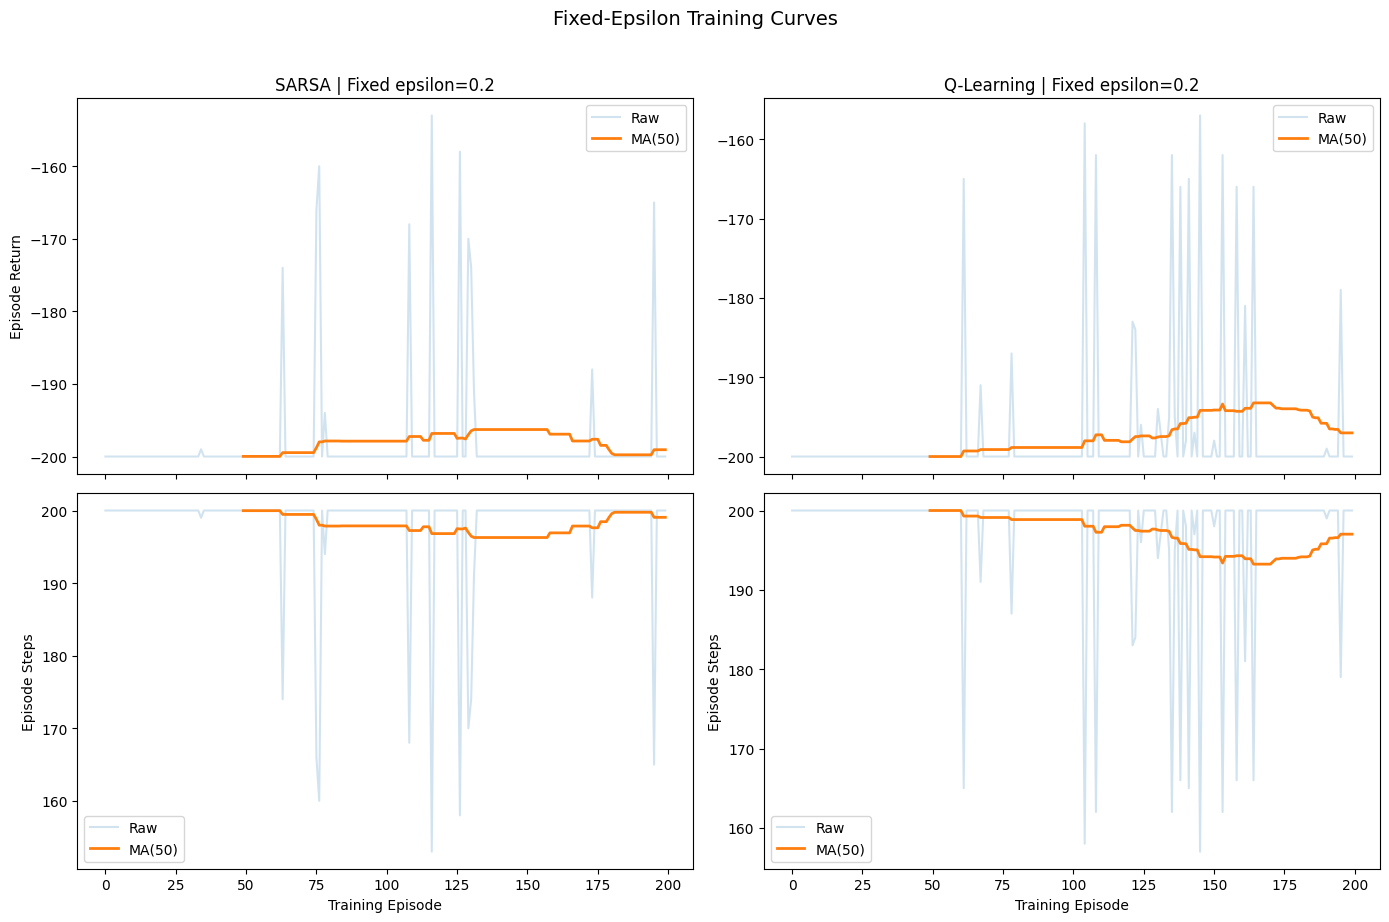

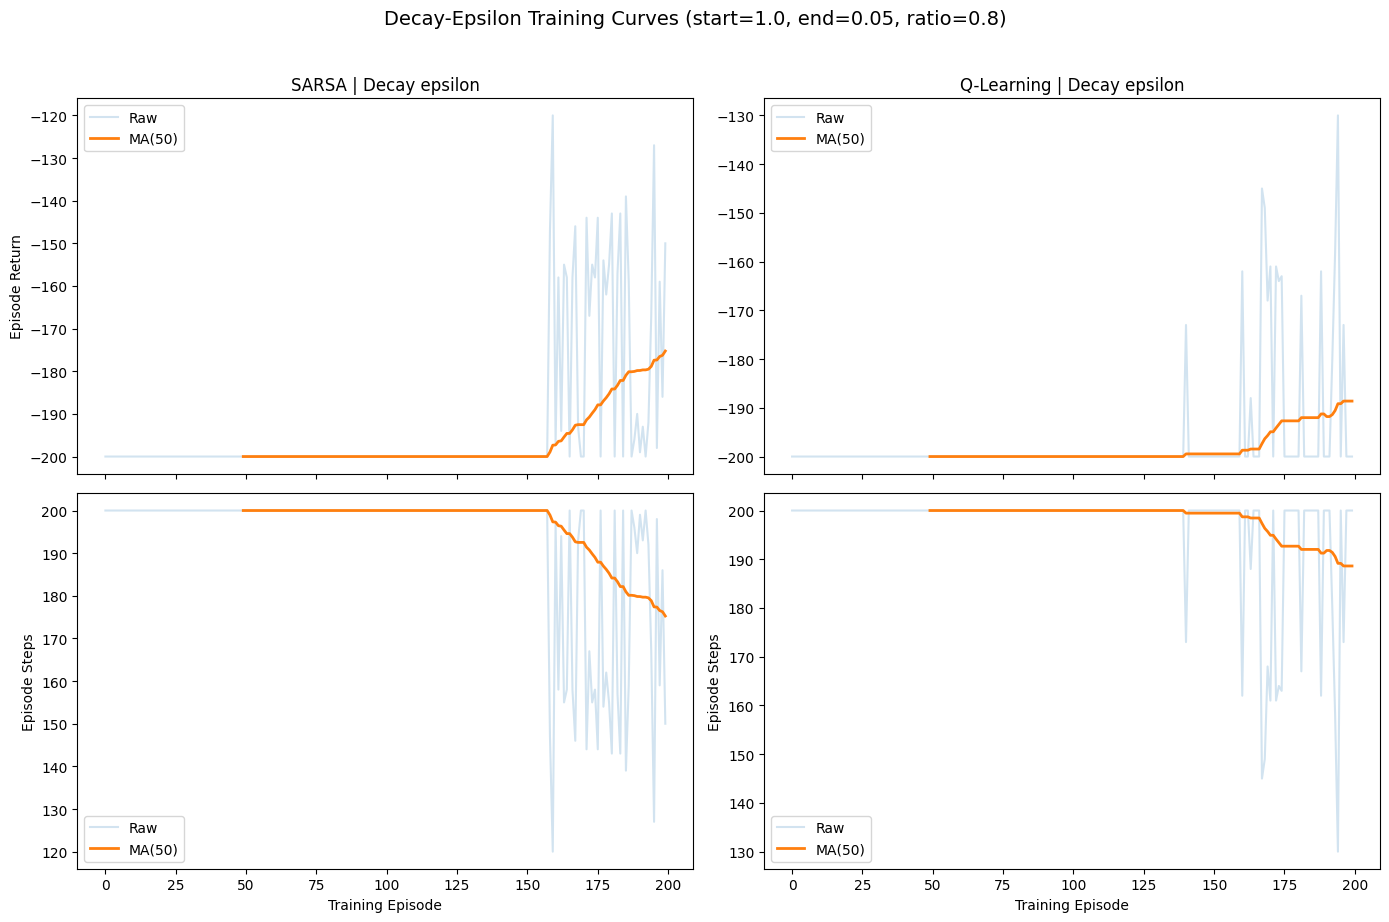

In [ ]:
# Plot learning curves: 

window = 50
episodes = np.arange(NUM_EPISODES_EXP)
ma_x = np.arange(window - 1, NUM_EPISODES_EXP)

fig, ax = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

# --- Episodic Returns ---
ax[0, 0].plot(episodes, sarsa_fixed["returns"], alpha=0.2, label="Raw")
ax[0, 0].plot(ma_x, moving_average(sarsa_fixed["returns"], window), lw=2, label=f"MA({window})")
ax[0, 0].set_title(f"SARSA | Fixed epsilon={epsilon_fixed}")
ax[0, 0].set_ylabel("Episode Return")
ax[0, 0].legend()

ax[0, 1].plot(episodes, q_fixed["returns"], alpha=0.2, label="Raw")
ax[0, 1].plot(ma_x, moving_average(q_fixed["returns"], window), lw=2, label=f"MA({window})")
ax[0, 1].set_title(f"Q-Learning | Fixed epsilon={epsilon_fixed}")
ax[0, 1].legend()

# --- Episode Lengths ---
ax[1, 0].plot(episodes, sarsa_fixed["lengths"], alpha=0.2, label="Raw")
ax[1, 0].plot(ma_x, moving_average(sarsa_fixed["lengths"], window), lw=2, label=f"MA({window})")
ax[1, 0].set_ylabel("Episode Steps")
ax[1, 0].set_xlabel("Training Episode")
ax[1, 0].legend()

ax[1, 1].plot(episodes, q_fixed["lengths"], alpha=0.2, label="Raw")
ax[1, 1].plot(ma_x, moving_average(q_fixed["lengths"], window), lw=2, label=f"MA({window})")
ax[1, 1].set_ylabel("Episode Steps")
ax[1, 1].set_xlabel("Training Episode")
ax[1, 1].legend()

plt.suptitle("Fixed-Epsilon Training Curves", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Decay comparison (same plotting style)
fig2, ax2 = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

ax2[0, 0].plot(episodes, sarsa_decay["returns"], alpha=0.2, label="Raw")
ax2[0, 0].plot(ma_x, moving_average(sarsa_decay["returns"], window), lw=2, label=f"MA({window})")
ax2[0, 0].set_title("SARSA | Decay epsilon")
ax2[0, 0].set_ylabel("Episode Return")
ax2[0, 0].legend()

ax2[0, 1].plot(episodes, q_decay["returns"], alpha=0.2, label="Raw")
ax2[0, 1].plot(ma_x, moving_average(q_decay["returns"], window), lw=2, label=f"MA({window})")
ax2[0, 1].set_title("Q-Learning | Decay epsilon")
ax2[0, 1].legend()

ax2[1, 0].plot(episodes, sarsa_decay["lengths"], alpha=0.2, label="Raw")
ax2[1, 0].plot(ma_x, moving_average(sarsa_decay["lengths"], window), lw=2, label=f"MA({window})")
ax2[1, 0].set_ylabel("Episode Steps")
ax2[1, 0].set_xlabel("Training Episode")
ax2[1, 0].legend()

ax2[1, 1].plot(episodes, q_decay["lengths"], alpha=0.2, label="Raw")
ax2[1, 1].plot(ma_x, moving_average(q_decay["lengths"], window), lw=2, label=f"MA({window})")
ax2[1, 1].set_ylabel("Episode Steps")
ax2[1, 1].set_xlabel("Training Episode")
ax2[1, 1].legend()

plt.suptitle(
    f"Decay-Epsilon Training Curves (start={epsilon_start}, end={epsilon_end}, ratio={epsilon_decay_ratio})",
    y=1.02,
    fontsize=14,
 )
plt.tight_layout()
plt.show()

# Experiment Notes

We now train both **SARSA** and **Q-Learning** under two epsilon strategies:
1. **Fixed epsilon** (constant exploration during training).
2. **Decay epsilon** (linearly annealed exploration).

Both algorithms use identical environment, tile-coding configuration, and optimizer settings for fair comparison.

In [32]:
# Optional: record greedy videos from trained fixed-epsilon policies
from gymnasium.wrappers import RecordVideo

def record_greedy_video(weights, tc_obj, video_folder, rng_obj, tag="agent"):
    env_vid = RecordVideo(
        gym.make("MountainCar-v0", render_mode="rgb_array"),
        video_folder=video_folder,
        episode_trigger=lambda x: True,
        name_prefix=tag,
    )
    state, _ = env_vid.reset()
    done = False
    while not done:
        action = epsilon_greedy(weights, tc_obj, state, epsilon=0.0, rng=rng_obj)  # greedy rollout
        state, _, terminated, truncated, _ = env_vid.step(action)
        done = terminated or truncated
    env_vid.close()

# Record one episode for each fixed-epsilon trained agent
record_greedy_video(sarsa_decay["weights"], sarsa_decay["tc"], "sarsa_videos", sarsa_decay["rng"], tag="sarsa_decay")
record_greedy_video(q_decay["weights"], q_decay["tc"], "qlearning_videos", q_decay["rng"], tag="qlearning_decay")

record_greedy_video(sarsa_fixed["weights"], sarsa_fixed["tc"], "sarsa_videos", sarsa_fixed["rng"], tag="sarsa_fixed")
record_greedy_video(q_fixed["weights"], q_fixed["tc"], "qlearning_videos", q_fixed["rng"], tag="qlearning_fixed")

/home/hegemon/RL-Assignments/env/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/hegemon/RL-Assignments/Assignment-1/1_SARSA-vs-Q/sarsa_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/home/hegemon/RL-Assignments/env/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/hegemon/RL-Assignments/Assignment-1/1_SARSA-vs-Q/qlearning_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


# Videos
## SARSA Videos
### Fixed Epsilon
<video controls width="320" height="240">
  <source src="sarsa_videos/sarsa_fixed-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

### Decaying Epsilon
<video controls width="320" height="240">
  <source src="sarsa_videos/sarsa_decay-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

## Q-Learning Videos
### Fixed Epsilon
<video controls width="320" height="240">
  <source src="qlearning_videos/qlearning_fixed-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

### Decaying Epsilon
<video controls width="320" height="240">
  <source src="qlearning_videos/qlearning_decay-episode-0.mp4" type="video/mp4">
  Your browser does not support the video tag.
</video>

### Compare epsilon schedules and print compact summary metrics

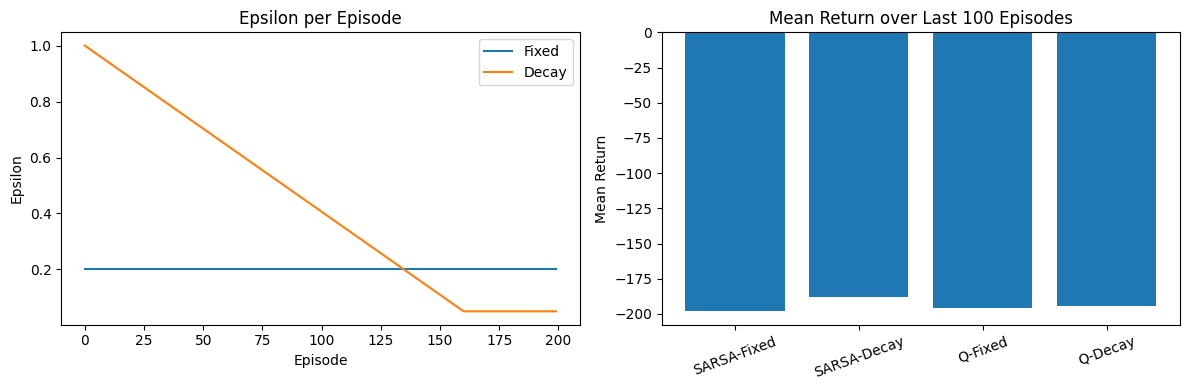

Tail metrics (last 100 episodes):
SARSA fixed  : return=-197.67, steps=197.67
SARSA decay  : return=-187.63, steps=187.63
Q fixed      : return=-195.60, steps=195.60
Q decay      : return=-194.04, steps=194.04


In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(sarsa_fixed["epsilons"], label="Fixed")
ax[0].plot(sarsa_decay["epsilons"], label="Decay")
ax[0].set_title("Epsilon per Episode")
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Epsilon")
ax[0].legend()

tail = 100
labels = ["SARSA-Fixed", "SARSA-Decay", "Q-Fixed", "Q-Decay"]
tail_returns = [
    sarsa_fixed["returns"][-tail:].mean(),
    sarsa_decay["returns"][-tail:].mean(),
    q_fixed["returns"][-tail:].mean(),
    q_decay["returns"][-tail:].mean(),
]
ax[1].bar(labels, tail_returns)
ax[1].set_title(f"Mean Return over Last {tail} Episodes")
ax[1].set_ylabel("Mean Return")
ax[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("Tail metrics (last 100 episodes):")
print(f"SARSA fixed  : return={sarsa_fixed['returns'][-100:].mean():.2f}, steps={sarsa_fixed['lengths'][-100:].mean():.2f}")
print(f"SARSA decay  : return={sarsa_decay['returns'][-100:].mean():.2f}, steps={sarsa_decay['lengths'][-100:].mean():.2f}")
print(f"Q fixed      : return={q_fixed['returns'][-100:].mean():.2f}, steps={q_fixed['lengths'][-100:].mean():.2f}")
print(f"Q decay      : return={q_decay['returns'][-100:].mean():.2f}, steps={q_decay['lengths'][-100:].mean():.2f}")

# Sensitivity Analysis

Using the **fixed epsilon** implementation, we evaluate both algorithms over a grid of:
- Learning rate $\alpha \in \{0.1, 0.01, 0.001\}$
- Exploration rate $\epsilon \in \{0.1, 0.01, 0.001\}$

For each pair, we train from scratch and summarize performance by the mean return and mean episode length over the last $N$ episodes.

Training SARSA (fixed):   0%|          | 0/200 [00:00<?, ?it/s]

Training Q-Learning (fixed): 100%|██████████| 200/200 [00:50<00:00,  3.96it/s]


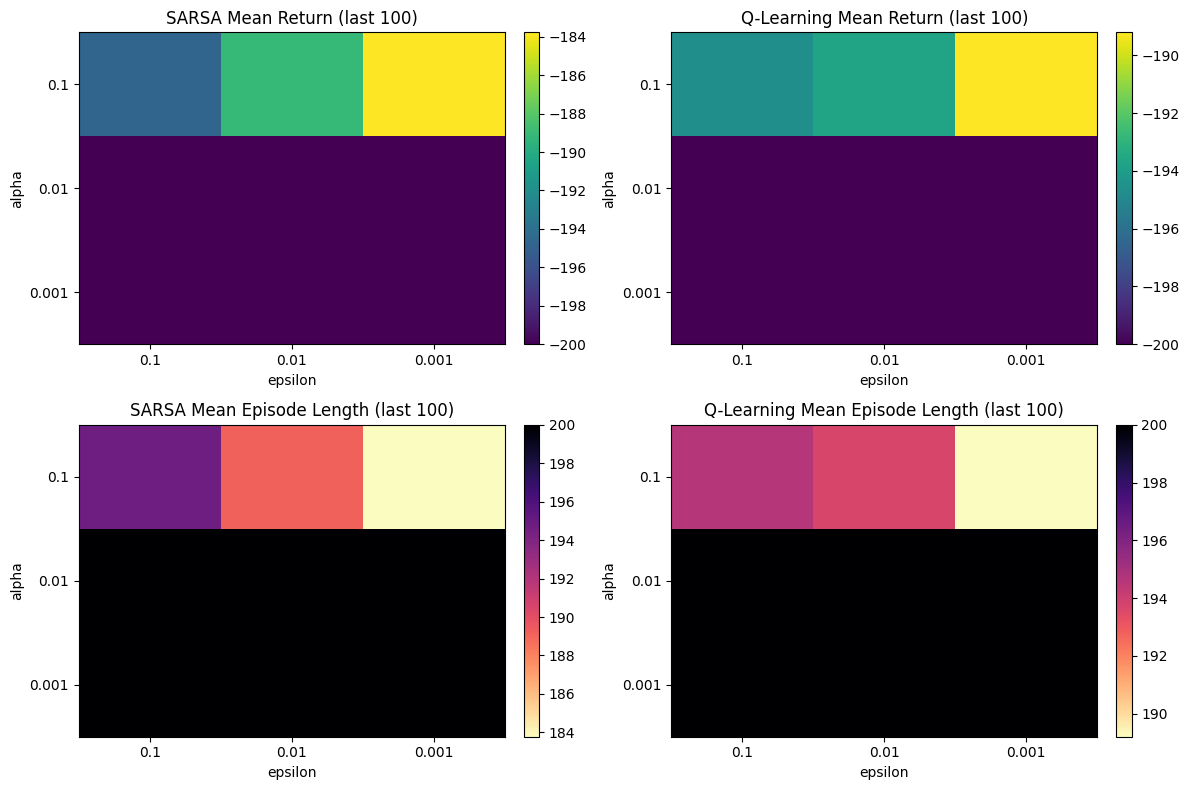

SARSA best (fixed epsilon) -> alpha=0.1, epsilon=0.001, mean_return=-183.77, mean_length=183.77
Q-Learning best (fixed epsilon) -> alpha=0.1, epsilon=0.001, mean_return=-189.20, mean_length=189.20


In [34]:
# Fixed-epsilon sensitivity analysis for SARSA and Q-Learning

alpha_values = np.array([0.1, 0.01, 0.001], dtype=np.float64)
epsilon_values = np.array([0.1, 0.01, 0.001], dtype=np.float64)

SENS_EPISODES = NUM_EPISODES
EVAL_TAIL = 100  # metrics computed over last N episodes


def run_fixed_grid_search(train_fn, alpha_grid, epsilon_grid, episodes=SENS_EPISODES, seed_base=1234):
    mean_returns = np.zeros((len(alpha_grid), len(epsilon_grid)), dtype=np.float64)
    mean_lengths = np.zeros((len(alpha_grid), len(epsilon_grid)), dtype=np.float64)

    for i, alpha_raw in enumerate(alpha_grid):
        for j, epsilon_fixed in enumerate(epsilon_grid):
            out = train_fn(
                num_episodes=episodes,
                alpha=alpha_raw / n_tilings,  # keep tile-coding scaling consistent with earlier sections
                gamma=gamma,
                n_tilings=n_tilings,
                bins=bins,
                epsilon_mode="fixed",
                epsilon_fixed=epsilon_fixed,
                seed=seed_base + 100 * i + j,
            )
            mean_returns[i, j] = out["returns"][-EVAL_TAIL:].mean()
            mean_lengths[i, j] = out["lengths"][-EVAL_TAIL:].mean()

    return mean_returns, mean_lengths


sarsa_ret_grid, sarsa_len_grid = run_fixed_grid_search(
    train_sarsa_tile, alpha_values, epsilon_values, episodes=SENS_EPISODES, seed_base=1200
)
q_ret_grid, q_len_grid = run_fixed_grid_search(
    train_q_learning_tile, alpha_values, epsilon_values, episodes=SENS_EPISODES, seed_base=2200
)

# Plot: higher mean return is better (less negative), lower episode length is better
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# SARSA return heatmap
im = ax[0, 0].imshow(sarsa_ret_grid, cmap="viridis", aspect="auto")
ax[0, 0].set_title(f"SARSA Mean Return (last {EVAL_TAIL})")
ax[0, 0].set_xticks(np.arange(len(epsilon_values)))
ax[0, 0].set_yticks(np.arange(len(alpha_values)))
ax[0, 0].set_xticklabels(epsilon_values)
ax[0, 0].set_yticklabels(alpha_values)
ax[0, 0].set_xlabel("epsilon")
ax[0, 0].set_ylabel("alpha")
fig.colorbar(im, ax=ax[0, 0], fraction=0.046, pad=0.04)

# Q-Learning return heatmap
im = ax[0, 1].imshow(q_ret_grid, cmap="viridis", aspect="auto")
ax[0, 1].set_title(f"Q-Learning Mean Return (last {EVAL_TAIL})")
ax[0, 1].set_xticks(np.arange(len(epsilon_values)))
ax[0, 1].set_yticks(np.arange(len(alpha_values)))
ax[0, 1].set_xticklabels(epsilon_values)
ax[0, 1].set_yticklabels(alpha_values)
ax[0, 1].set_xlabel("epsilon")
ax[0, 1].set_ylabel("alpha")
fig.colorbar(im, ax=ax[0, 1], fraction=0.046, pad=0.04)

# SARSA episode-length heatmap
im = ax[1, 0].imshow(sarsa_len_grid, cmap="magma_r", aspect="auto")
ax[1, 0].set_title(f"SARSA Mean Episode Length (last {EVAL_TAIL})")
ax[1, 0].set_xticks(np.arange(len(epsilon_values)))
ax[1, 0].set_yticks(np.arange(len(alpha_values)))
ax[1, 0].set_xticklabels(epsilon_values)
ax[1, 0].set_yticklabels(alpha_values)
ax[1, 0].set_xlabel("epsilon")
ax[1, 0].set_ylabel("alpha")
fig.colorbar(im, ax=ax[1, 0], fraction=0.046, pad=0.04)

# Q-Learning episode-length heatmap
im = ax[1, 1].imshow(q_len_grid, cmap="magma_r", aspect="auto")
ax[1, 1].set_title(f"Q-Learning Mean Episode Length (last {EVAL_TAIL})")
ax[1, 1].set_xticks(np.arange(len(epsilon_values)))
ax[1, 1].set_yticks(np.arange(len(alpha_values)))
ax[1, 1].set_xticklabels(epsilon_values)
ax[1, 1].set_yticklabels(alpha_values)
ax[1, 1].set_xlabel("epsilon")
ax[1, 1].set_ylabel("alpha")
fig.colorbar(im, ax=ax[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Report best fixed-epsilon setting by mean return
def print_best_by_return(name, ret_grid, len_grid):
    best_idx = np.unravel_index(np.argmax(ret_grid), ret_grid.shape)
    best_alpha = alpha_values[best_idx[0]]
    best_epsilon = epsilon_values[best_idx[1]]
    best_ret = ret_grid[best_idx]
    best_len = len_grid[best_idx]
    print(
        f"{name} best (fixed epsilon) -> alpha={best_alpha}, epsilon={best_epsilon}, "
        f"mean_return={best_ret:.2f}, mean_length={best_len:.2f}"
    )

print_best_by_return("SARSA", sarsa_ret_grid, sarsa_len_grid)
print_best_by_return("Q-Learning", q_ret_grid, q_len_grid)

# Tasks

1. Implement SARSA and Q-Learning with function approximation
2. Train both agents under identical experimental settings
3. Plot Learning Curves showing episodic return versus training episodes
4. Analyze the Sensitivity of both algorithms to the learning rate and exploration parameter

## Task 1

Implemented both!

## Task 2
For function approximation, I used tile coding with n_tilings = 8, bins = (8, 8), gamma = 1.0, alpha = 0.4 / n_tilings (This alpha was recommended in the text book).

For epsilon, I used 2 strategies:
1. Fixed Epsilon of 0.2
2. Decaying Epsilon with 1.0 to 0.05 with epsilon decay ratio of 0.8!

The SARSA with Epsilon-Decay produced the best mean return and mean epsiode length.

## Task 3

![Learning Curves](task_3.png)


## Task 4

![Hyperparameter Sensitivity](task_4.png)


**SARSA best** (_fixed epsilon_):
1. alpha=0.1, 
2. epsilon=0.001, 
3. mean_return=-183.77, 
4. mean_length=183.77

**Q-Learning best** (_fixed epsilon_):
1. alpha=0.1, 
2. epsilon=0.001, 
3. mean_return=-189.20, 
4. mean_length=189.20


**Points**:
1. With alpha less than 0.1, both algorithms fail to learn effectively, resulting in poor performance.
2. SARSA does better than Q-Learning across all hyperparameter settings, likely due to its on-policy nature which allows it to learn more effectively in this environment.

# Analysis Questions

1. Compare learning behaviour of SARSA and Q-Learning. Are there qualitative differences in stability or convergence?
2. How does function approximation affect learning compared to the tabular case?
3. Discuss the role of off-policy versus on-policy updates in the environment

## Question 1
#### Are there qualitative differences in stability or convergence between SARSA and Q-Learning?

Definitely, with linear function approximation, SARSA is guaranteed to converge to a fixed point $w_{TD}$. 
In contrast, repurposing the Q-Learning algorithm with function approximation can lead to divergence.
I had to manually tune the learning rate and exploration rate to prevent divergence in Q-Learning, while SARSA was more robust to hyperparameter settings.

Also, I have observed that training SARSA agent was tad bit faster than Q-Learning agent, which is consistent with the fact that SARSA is on-policy and can learn more effectively in this environment.

## Question 2
#### How does function approximation affect learning compared to the tabular case?

Function approximation allows us to generalize across states and actions, which is essential in continuous state spaces like Mountain Car. However, it also introduces challenges such as convergence issues, and most importantly we loose the **policy improvement guarantee** that we have in the tabular case. In the tabular case, both SARSA and Q-Learning are guaranteed to converge to the optimal policy under certain conditions. However, with function approximation, especially with linear function approximation, we can only guarantee convergence to a fixed point, which may not be the optimal policy. This is particularly evident in the case of Q-Learning, where divergence can occur if the learning rate and exploration rate are not carefully tuned.

## Question 3
#### Discuss the role of off-policy versus on-policy updates in the environment

In this environment, SARSA uses on-policy updates, meaning it updates its action-value estimates based on the actions actually taken by the current policy. This makes SARSA more conservative and stable, as it accounts for the exploration strategy in its updates. On the other hand, Q-Learning uses off-policy updates, meaning it updates its action-value estimates based on the greedy action, regardless of the action taken by the current policy. This can lead to more aggressive learning and potentially higher returns, but also increases the risk of divergence, especially when combined with function approximation.